<h1><b>Coin Detection by YOLOv8n

10원, 50원, 100원, 500원 동전 커스텀 데이터를 YOLO format으로 세팅하여 모델 학습을 진행하고자 한다.
<br>그 후, 해당 모델을 활용하여 현재 인식된 동전의 총액을 산출하고자 한다.

<h3><b>1. Custom data setting</b></h3>

<b><h5>yaml 파일 생성 및 코드 구성하기</b></h5>

<font size=2>모델 train에 사용되는 <b>.yaml 파일을 생성</b>하고 다음과 같이 작성해야 한다. 
<br>names에는 0~n의 라벨과 라벨명을 적고
<br>train, val, test에는 각각 폴더 절대 경로를 입력한다.

In [1]:
import yaml

# Define dataset information
dataset_info = {
    "path": "C:/Users/jjang/Downloads/apple2orange/train/",
    "train": "C:/Users/jjang/Downloads/apple2orange/train/images",  # train images (relative to 'path')
    "val": "C:/Users/jjang/Downloads/apple2orange/train/images",    # val images (relative to 'path')
    "test": "C:/Users/jjang/Downloads/apple2orange/train/images"    # test images (optional)
}

# Define class names
class_names = {
    0: "apple",
    1: "orange"
}

# Combine dataset information and class names
data = {"names": class_names}
data.update(dataset_info)

# Write data to YAML file
output_file = "fruit.yaml"
with open(output_file, 'w') as yaml_file:
    yaml.dump(data, yaml_file)

print(f"YAML file '{output_file}' has been created successfully.")

YAML file 'fruit.yaml' has been created successfully.


<b><h5>데이터 아키텍쳐 구성하기</b></h5>

<font size=2>yaml 파일에서 설정한 디렉토리 위치대로 구조를 설정하고
<br>각 폴더에는 <b>images와 labels 폴더를 생성</b>한다.
<br>현재 각 폴더에 있는 coin_10 이하 이미지 데이터 폴더들은 images 폴더 안으로 넣는다.

In [3]:
!pip install labelme2yolov8
# !labelme2yolo --json_dir coin/train/labels --val_size 0.15 --test_size 0.15

In [4]:
!python coin/labelme2yolo.py --json_dir coin/train/labels 

Converting 007__500 Won_south_korea.json for train ...
Converting 028__500 Won_south_korea.json for train ...
Converting 015__500 Won_south_korea.json for train ...
Converting 033__10 Won_south_korea.json for train ...
Converting 018__500 Won_south_korea.json for train ...
Converting 011__10 Won_south_korea.json for train ...
Converting 002__50 Won_south_korea.json for train ...
Converting 012__50 Won_south_korea.json for train ...
Converting 005__500 Won_south_korea.json for train ...
Converting 029__50 Won_south_korea.json for train ...
Converting 020__50 Won_south_korea.json for train ...
Converting 032__100 Won_south_korea.json for train ...
Converting 028__100 Won_south_korea.json for train ...
Converting 022__50 Won_south_korea.json for train ...
Converting 008__100 Won_south_korea.json for train ...
Converting 014__100 Won_south_korea.json for train ...
Converting 020__10 Won_south_korea.json for train ...
Converting 016__500 Won_south_korea.json for train ...
Converting 016__10

coin/train/labels 안에 생성된 YOLODataset 폴더를 coin 폴더로 이동시킨다. 
<br>그리고나서 위치가 이동되었기 때문에 YOLODataset 안에 있는 dataset.yaml가 수정되어야 한다. 
<br>우리가 수정해야할 부분은 train과 val의 경로이다. 
<br>train: coin/YOLODataset/images/train/
<br>val: coin/YOLODataset/images/val/
<br>이런식으로 수정하여 저장한다

In [26]:
!mv coin/train/labels/YOLODataset /coin/

'mv'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


<h3><b>2. Custom data Train</b></h3>

<font size=2>이제 YOLODataset에 있는 사진과 라벨링 결과를 활용하여 모델을 학습하고자 한다.

In [2]:
from ultralytics import YOLO
 
# Load the model.
model = YOLO('yolov8n.pt')
 
# Training.
model.train(data='fruit.yaml', epochs=50, batch=32, imgsz=416, name='fruit')

# !yolo task=detect mode=train model=yolov8n.pt data=coin/YOLODataset/dataset.yaml epochs=60 imgsz=416 plots=True

c:\Users\jjang\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\jjang\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\Users\jjang\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.23-246-g3d31191b-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


100%|██████████| 6.23M/6.23M [00:01<00:00, 6.27MB/s]


New https://pypi.org/project/ultralytics/8.2.32 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.45  Python-3.10.9 torch-2.0.1+cpu CPU (12th Gen Intel Core(TM) i7-12700F)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=fruit.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=fruit, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fals

train: Scanning C:\Users\jjang\Downloads\apple2orange\train\labels... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<00:00, 982.52it/s]

train: New cache created: C:\Users\jjang\Downloads\apple2orange\train\labels.cache



val: Scanning C:\Users\jjang\Downloads\apple2orange\train\labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]


Plotting labels to runs\detect\fruit\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 416 train, 416 val
Using 0 dataloader workers
Logging results to runs\detect\fruit
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/4 [00:01<?, ?it/s]


IndexError: index 2 is out of bounds for dimension 1 with size 2

In [6]:
!dir runs/detect/coin_1/

�Ű� ���� ������ Ʋ���ϴ� - "detect".


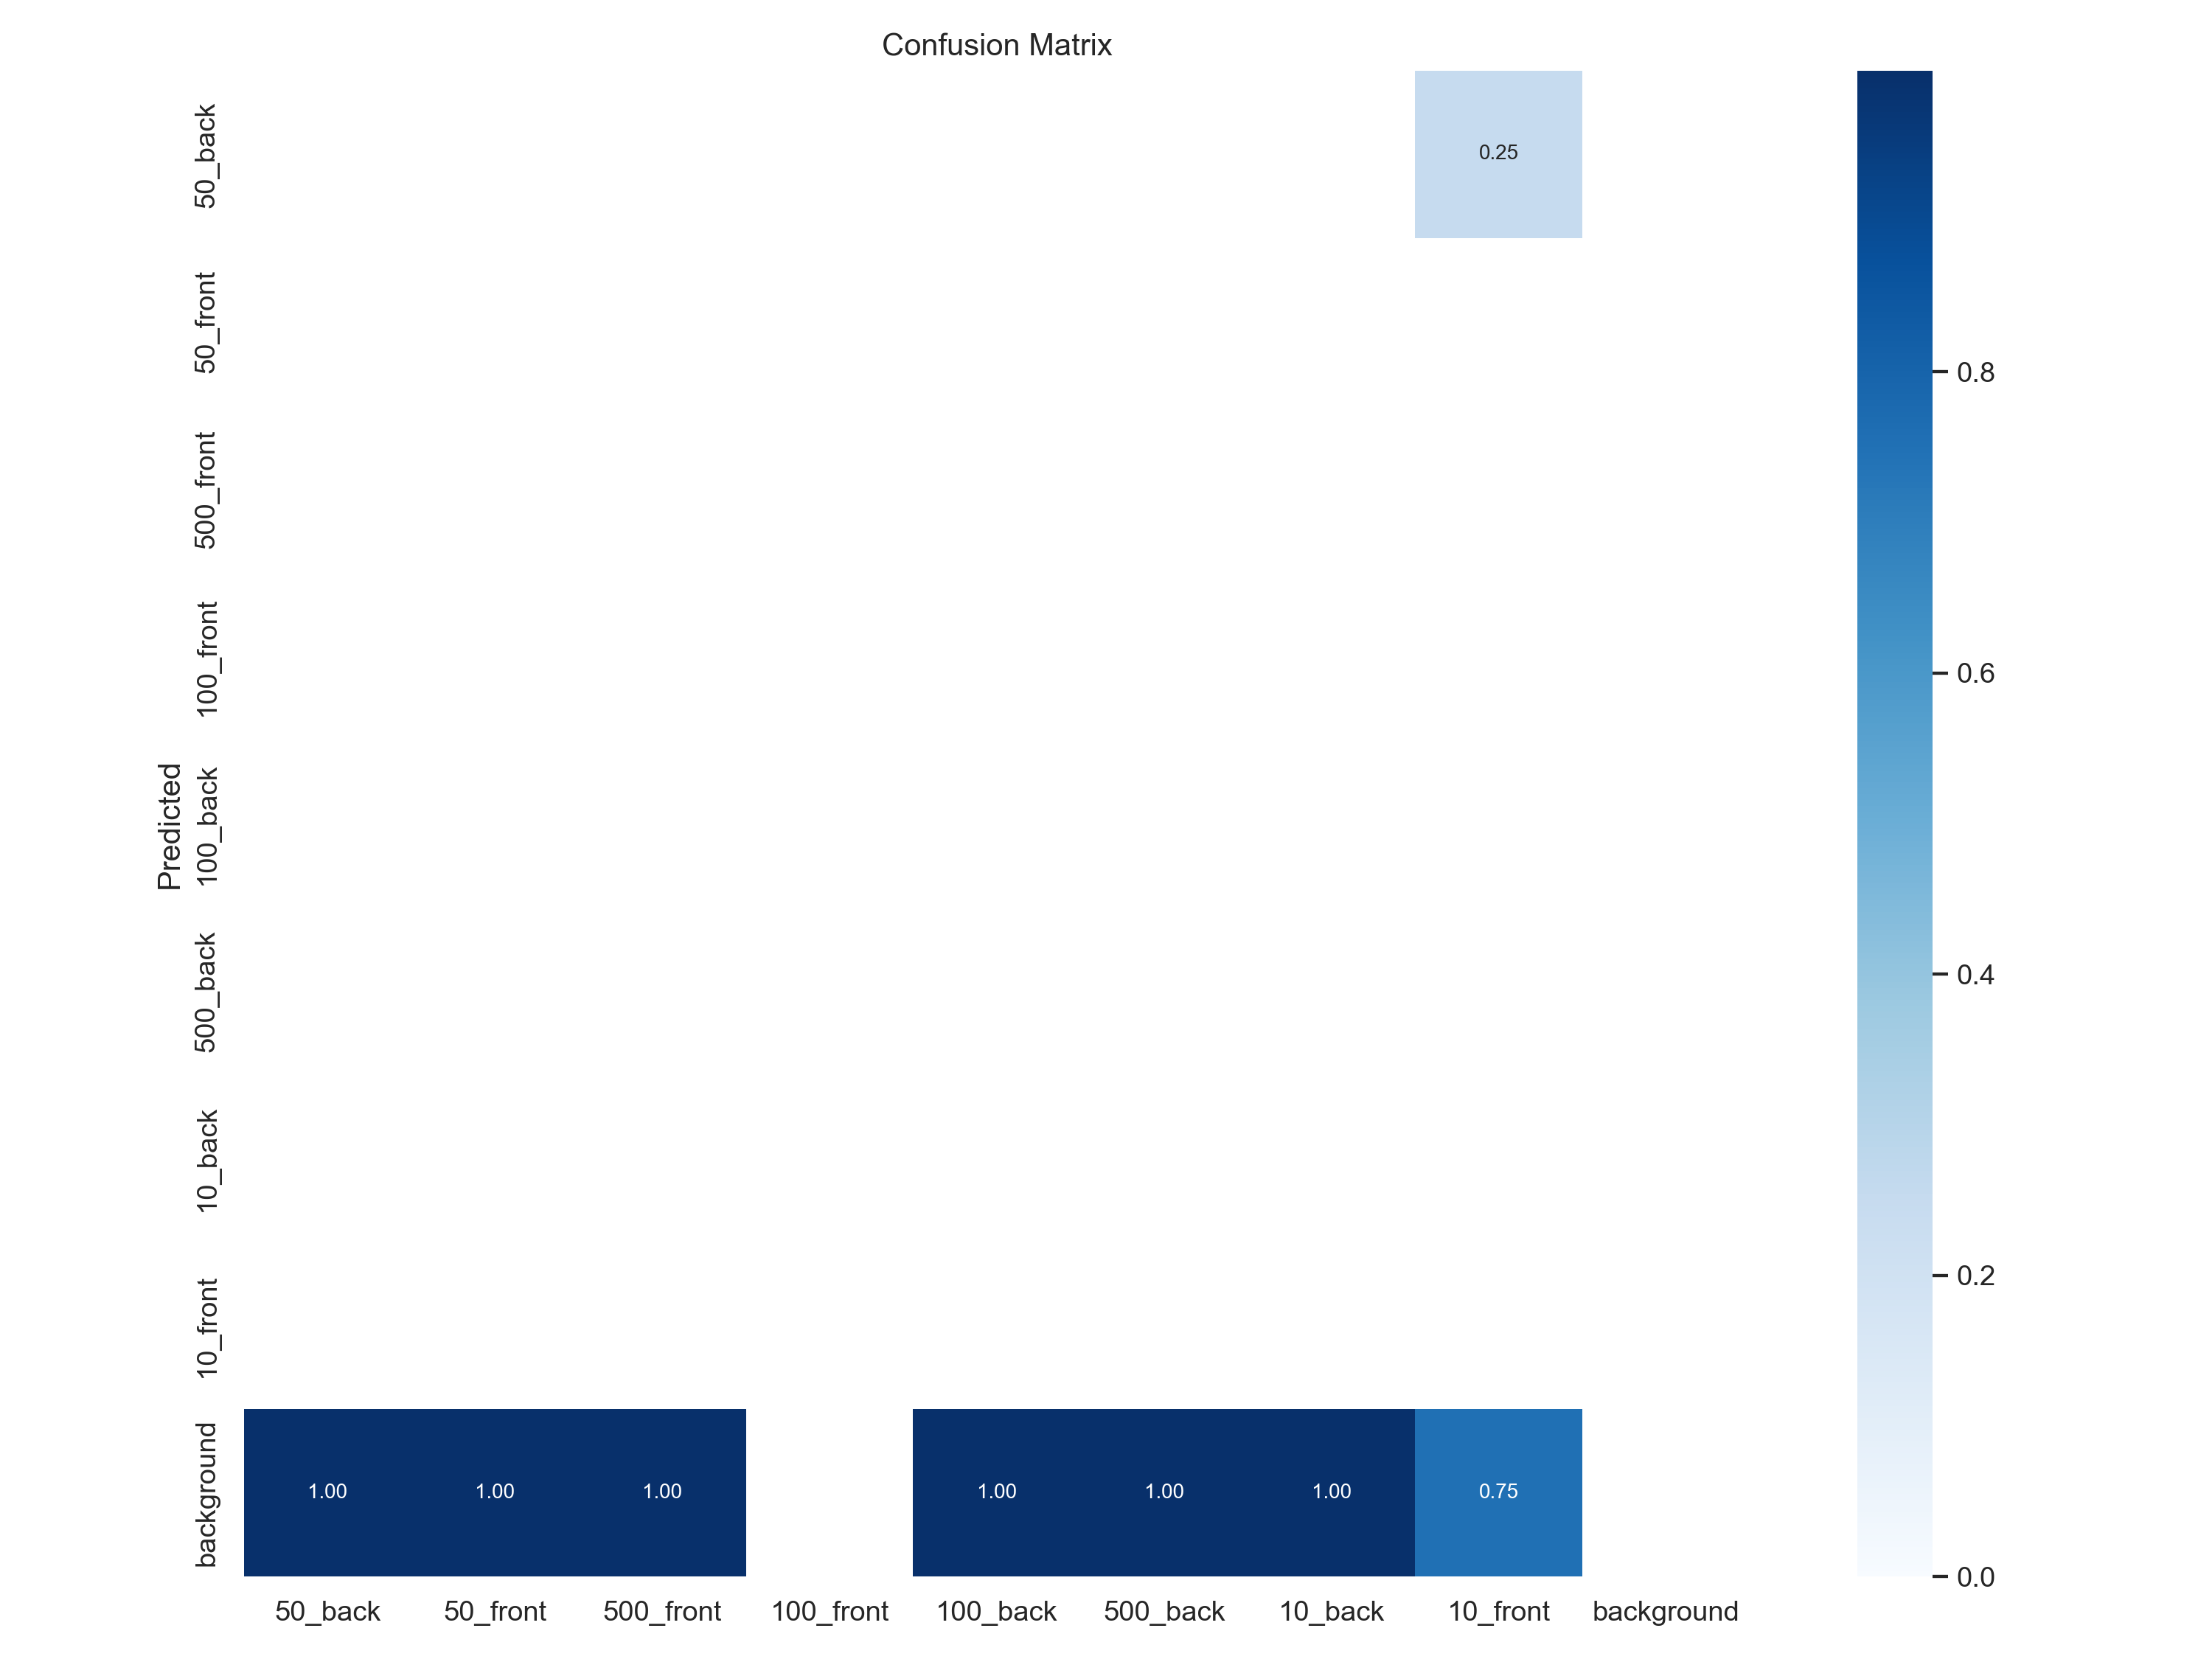

In [7]:
from IPython.display import Image

Image(filename=f'runs/detect/coin_1/confusion_matrix.png', width=600)

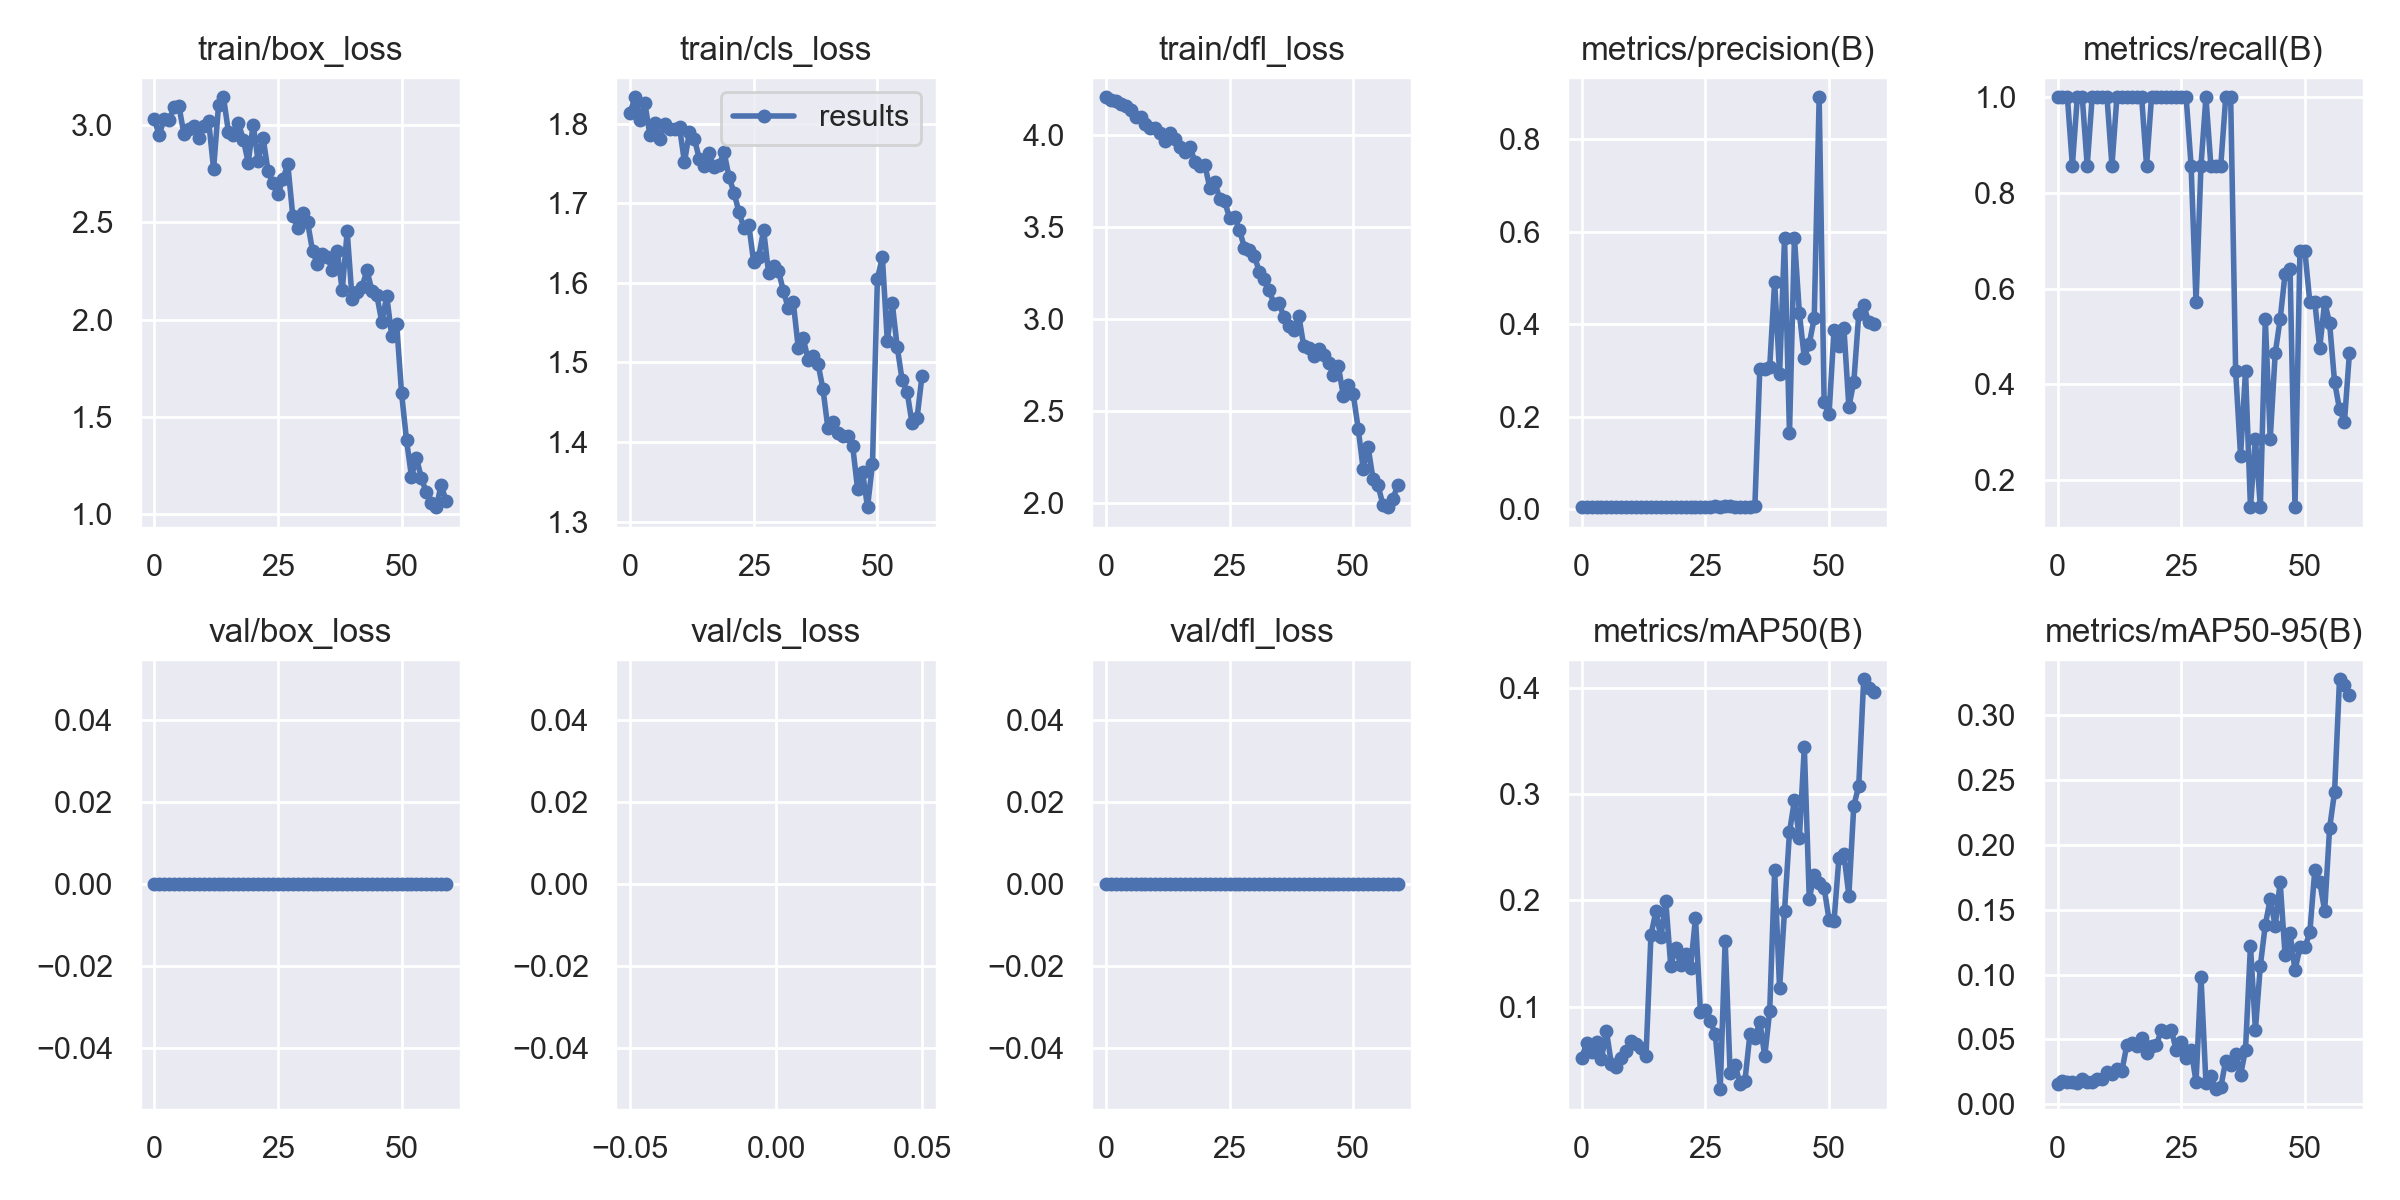

In [8]:
from IPython.display import Image

Image(filename=f'runs/detect/coin_1/results.png', width=600)

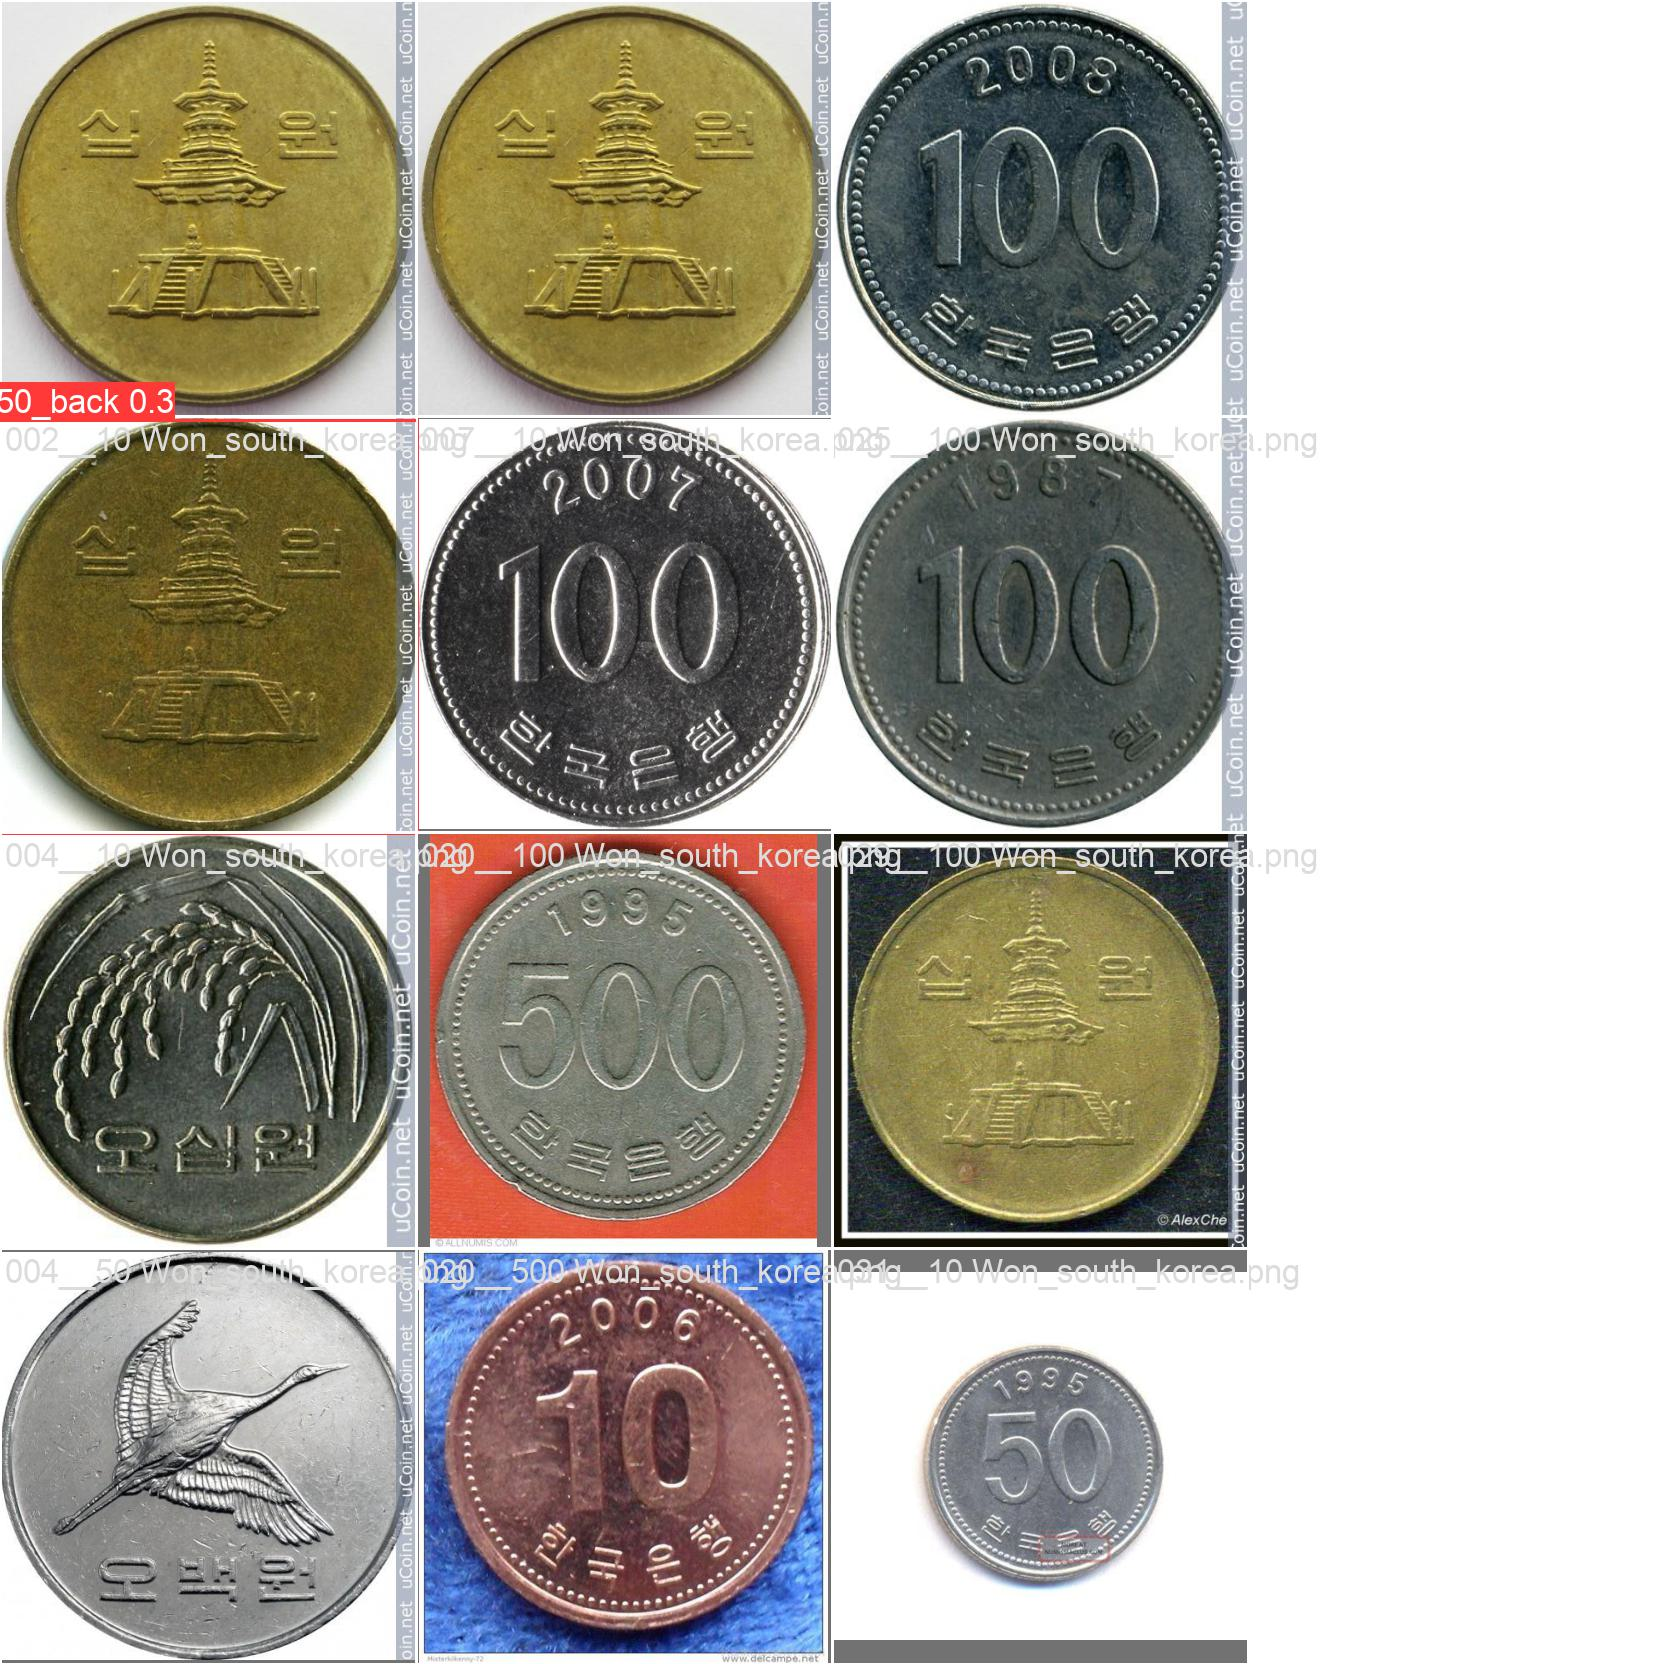

In [9]:
from IPython.display import Image

Image(filename=f'runs/detect/coin_1/val_batch0_pred.jpg', width=600)

<h3><b>3. Validate Custom model</b></h3>

<font size=2>이제 YOLODataset에 있는 사진과 라벨링 결과를 활용하여 모델을 학습하고자 한다.

In [10]:
!yolo task=detect mode=val model=runs/detect/coin_1/weights/best.pt data=coin/YOLODataset/dataset.yaml

[2024-04-05 11:14:56,111][tensorflow][WARNING] - From C:\Users\jjang\anaconda3\lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



2024-04-05 11:14:52.421304: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Ultralytics YOLOv8.0.0  Python-3.10.9 torch-2.0.1+cpu CPU
Fusing layers... 
Model summary: 168 layers, 3007208 parameters, 0 gradients, 8.1 GFLOPs

val: Scanning C:\Users\jjang\Desktop\mechArm_jupyter\coin\YOLODataset\labels\val...:   0%|          | 0/12 [00:00<?, ?it/s]
val: Scanning C:\Users\jjang\Desktop\mechArm_jupyter\coin\YOLODataset\labels\val... 1 images, 0 backgrounds, 0 corrupt:   8%|▊         | 1/12 [00:03<00:39,  3.60s/it]
val: Scanning C:\Users\jjang\Desktop\mechArm_jupyter\coin\YOLODataset\labels\val... 12 images, 0 backgrounds, 0 corrupt: 100%|██████████| 12/12 [00:03<00:00,  3.32it/s]
val: WARNING  Cache directory C:\Users\jjang\Desktop\mechArm_jupyter\coin\YOLODataset\labels is no

<h3><b>4. Inference with Custom Model</b></h3>

<font size=2>이제 YOLODataset에 있는 사진과 라벨링 결과를 활용하여 모델을 학습하고자 한다.

In [12]:
!yolo task=detect mode=predict model=runs/detect/coin_1/weights/best.pt conf=0.7 source=coin/test/images save=True

[2024-04-05 11:18:22,234][tensorflow][WARNING] - From C:\Users\jjang\anaconda3\lib\site-packages\keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



2024-04-05 11:18:18.640373: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Ultralytics YOLOv8.0.0  Python-3.10.9 torch-2.0.1+cpu CPU
Fusing layers... 
Model summary: 168 layers, 3007208 parameters, 0 gradients, 8.1 GFLOPs
image 1/16 C:\Users\jjang\Desktop\mechArm_jupyter\coin\test\images\001__500 Won_south_korea.jpg: 640x640 88.9ms
image 2/16 C:\Users\jjang\Desktop\mechArm_jupyter\coin\test\images\002__500 Won_south_korea.jpg: 640x640 75.0ms
image 3/16 C:\Users\jjang\Desktop\mechArm_jupyter\coin\test\images\005__50 Won_south_korea.jpg: 640x640 78.1ms
image 4/16 C:\Users\jjang\Desktop\mechArm_jupyter\coin\test\images\006__100 Won_south_korea.jpg: 320x640 48.5ms
image 5/16 C:\Users\jjang\Desktop\mechArm_jupyter\coin\test\images\007__50 Won_south_korea.jpg: 640x640 78.7ms
i

<h3><b>5. 웹캠을 통한 실시간 모델 활용하기</b></h3>

<font size=2>이제 YOLODataset에 있는 사진과 라벨링 결과를 활용하여 모델을 학습하고자 한다.

In [4]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/detect/coin_1/weights/best.pt") 

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Perform prediction on the frame
    results = model(frame)
    
    # Show the frame
    cv2.imshow('Frame', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
import glob
from IPython.display import Image, display

for img_path in glob.glob(f'coin/test/images/*.jpg'):
    display(Image(filename=img_path, height=412))
    print("\n")

#### 데이터셋 yaml 파일 생성하기 